# Notebook 1 — Exploratory Data Analysis
**Project:** E-Commerce CLV Micro-Segmentation  
**Dataset:** Kaggle — E-Commerce Customer Behavior Dataset

---
**Sections:**
1. Load & inspect raw data
2. Missing values & data types
3. Univariate distributions
4. Bivariate analysis
5. Correlation heatmap
6. Categorical breakdowns
7. Key insights summary

In [1]:
import sys, os
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.dpi'] = 110

print('Libraries loaded ✅')

Libraries loaded ✅


## 1. Load & Inspect Raw Data

In [2]:
# Load from SQLite (already preprocessed)
conn = sqlite3.connect('../data/processed/customers_clean.db')
df = pd.read_sql('SELECT * FROM customers', conn)
conn.close()

print(f'Shape: {df.shape}')
df.head()

Shape: (350, 31)


,Customer Id,Gender,Age,City,Membership Type,Total Spend,Items Purchased,Average Rating,Discount Applied,Days Since Last Purchase,...,Purchase_Prob,CLV_Score,CLV_Band,Engagement_Score,Spend_Per_Item,KMeans_Cluster,KMeans_Segment,DBSCAN_Cluster,DBSCAN_Segment,Segment
0,101,Female,29,New York,Gold,1120.20,14,4.6,1,25,...,0.351852,362.612889,Low,0.648222,80.014286,2,At-Risk,0,Champions,At-Risk
1,102,Male,34,Los Angeles,Silver,780.50,11,4.1,0,18,...,0.238095,152.383333,Low,0.526952,70.954545,4,Segment 4,1,Loyalists,Segment 4
2,103,Female,43,Chicago,Bronze,510.75,9,3.4,1,42,...,0.055556,19.295000,Low,0.392095,56.750000,3,Lost,2,At-Risk,Lost
3,104,Male,30,San Francisco,Gold,1480.30,19,4.7,0,12,...,0.809524,1126.437809,High,0.886762,77.910526,1,Loyalists,3,Lost,Loyalists
4,105,Male,27,Miami,Silver,720.40,13,4.0,1,55,...,0.063492,36.591746,Low,0.506667,55.415385,5,Segment 5,4,Segment 4,Segment 5


In [3]:
print('Column names:')
print(df.columns.tolist())
print()
print('Data types:')
print(df.dtypes)

Column names:
['Customer Id', 'Gender', 'Age', 'City', 'Membership Type', 'Total Spend', 'Items Purchased', 'Average Rating', 'Discount Applied', 'Days Since Last Purchase', 'Satisfaction Level', 'Gender_Enc', 'City_Enc', 'Membership Type_Enc', 'Satisfaction Level_Enc', 'Age_Scaled', 'Days Since Last Purchase_Scaled', 'Total Spend_Scaled', 'Items Purchased_Scaled', 'Average Rating_Scaled', 'Discount Applied_Scaled', 'Purchase_Prob', 'CLV_Score', 'CLV_Band', 'Engagement_Score', 'Spend_Per_Item', 'KMeans_Cluster', 'KMeans_Segment', 'DBSCAN_Cluster', 'DBSCAN_Segment', 'Segment']

Data types:
Customer Id                          int64
Gender                              object
Age                                  int64
City                                object
Membership Type                     object
Total Spend                        float64
Items Purchased                      int64
Average Rating                     float64
Discount Applied                     int64
Days Since Last P

In [ ]:
df.describe().round(2)

## 2. Missing Values & Data Quality

In [4]:
missing = df.isnull().sum()
missing = missing[missing > 0]

if len(missing) == 0:
    print('✅ No missing values — preprocessing worked perfectly!')
else:
    print('Missing values found:')
    print(missing)

✅ No missing values — preprocessing worked perfectly!


In [5]:
print(f'Total rows     : {len(df):,}')
print(f'Duplicate rows : {df.duplicated().sum()}')
print(f'Unique customers: {df["Customer ID"].nunique() if "Customer ID" in df.columns else "N/A"}')

Total rows     : 350
Duplicate rows : 0
Unique customers: N/A


## 3. Univariate Distributions

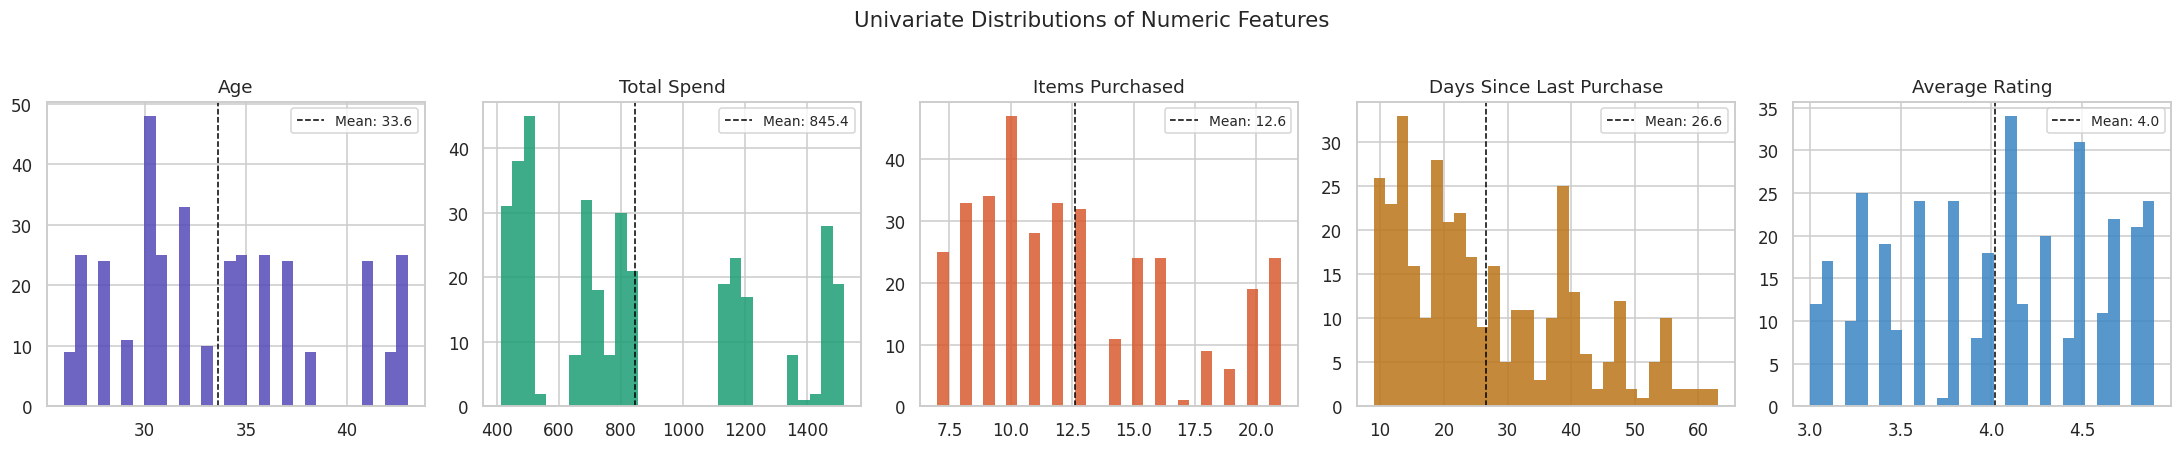

Saved: eda_univariate.png ✅


In [6]:
num_cols = ['Age', 'Total Spend', 'Items Purchased',
            'Days Since Last Purchase', 'Average Rating']
num_cols = [c for c in num_cols if c in df.columns]

fig, axes = plt.subplots(1, len(num_cols), figsize=(4 * len(num_cols), 4))
colors = ['#534AB7', '#1D9E75', '#D85A30', '#BA7517', '#3A85C3']

for ax, col, color in zip(axes, num_cols, colors):
    ax.hist(df[col].dropna(), bins=30, color=color, edgecolor='none', alpha=0.85)
    ax.set_title(col, fontsize=12)
    ax.set_xlabel('')
    mean_val = df[col].mean()
    ax.axvline(mean_val, color='black', linestyle='--', linewidth=1, label=f'Mean: {mean_val:.1f}')
    ax.legend(fontsize=9)

fig.suptitle('Univariate Distributions of Numeric Features', y=1.02, fontsize=14)
plt.tight_layout()
plt.savefig('eda_univariate.png', bbox_inches='tight')
plt.show()
print('Saved: eda_univariate.png ✅')

## 4. Bivariate Analysis

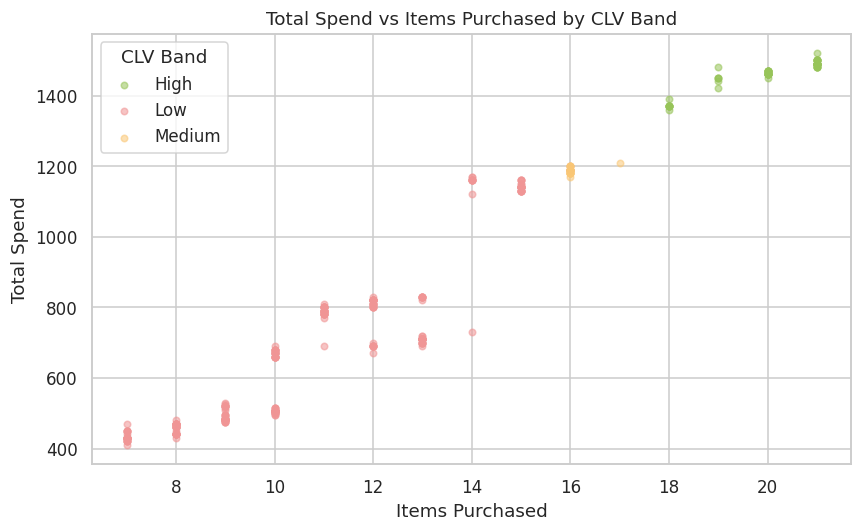

Saved: eda_scatter_clv.png ✅


In [7]:
# Total Spend vs Items Purchased — coloured by CLV Band
if 'CLV_Band' in df.columns and 'Total Spend' in df.columns:
    fig, ax = plt.subplots(figsize=(8, 5))
    palette = {'Low': '#F09595', 'Medium': '#FAC775', 'High': '#97C459'}
    for band, grp in df.groupby('CLV_Band'):
        ax.scatter(grp['Items Purchased'], grp['Total Spend'],
                   label=band, alpha=0.55, s=18,
                   color=palette.get(str(band), '#999'))
    ax.set_xlabel('Items Purchased')
    ax.set_ylabel('Total Spend')
    ax.set_title('Total Spend vs Items Purchased by CLV Band')
    ax.legend(title='CLV Band')
    plt.tight_layout()
    plt.savefig('eda_scatter_clv.png', bbox_inches='tight')
    plt.show()
    print('Saved: eda_scatter_clv.png ✅')

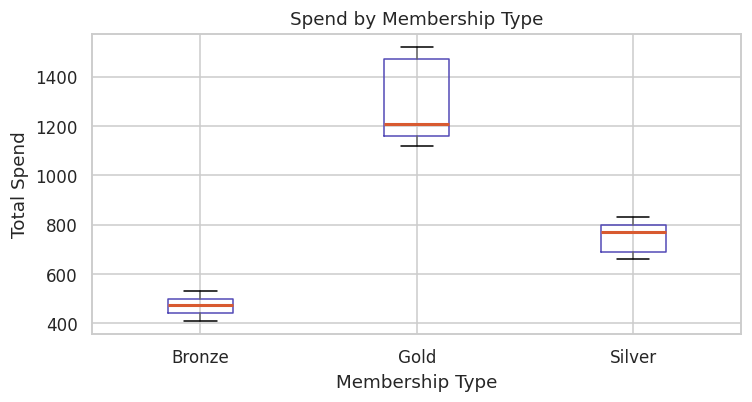

Saved: eda_spend_membership.png ✅


In [8]:
# Spend distribution by Membership Type
if 'Membership Type' in df.columns and 'Total Spend' in df.columns:
    fig, ax = plt.subplots(figsize=(7, 4))
    df.boxplot(column='Total Spend', by='Membership Type', ax=ax,
               boxprops=dict(color='#534AB7'),
               medianprops=dict(color='#D85A30', linewidth=2))
    ax.set_title('Spend by Membership Type')
    plt.suptitle('')
    ax.set_xlabel('Membership Type')
    ax.set_ylabel('Total Spend')
    plt.tight_layout()
    plt.savefig('eda_spend_membership.png', bbox_inches='tight')
    plt.show()
    print('Saved: eda_spend_membership.png ✅')

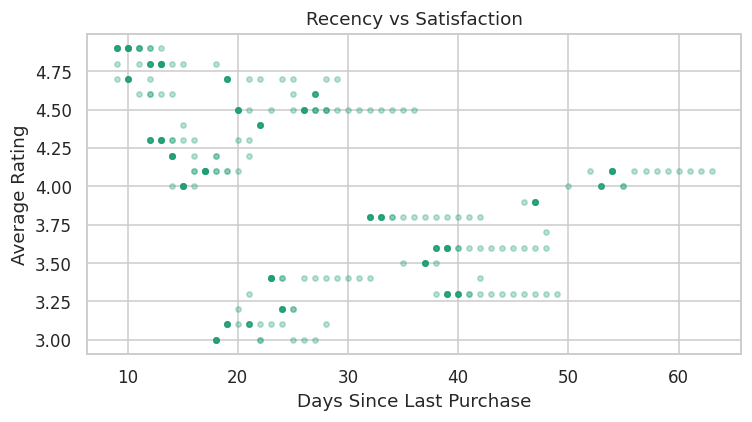

In [9]:
# Days Since Last Purchase vs Average Rating
if 'Days Since Last Purchase' in df.columns and 'Average Rating' in df.columns:
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.scatter(df['Days Since Last Purchase'], df['Average Rating'],
               alpha=0.3, s=12, color='#1D9E75')
    ax.set_xlabel('Days Since Last Purchase')
    ax.set_ylabel('Average Rating')
    ax.set_title('Recency vs Satisfaction')
    plt.tight_layout()
    plt.show()

## 5. Correlation Heatmap

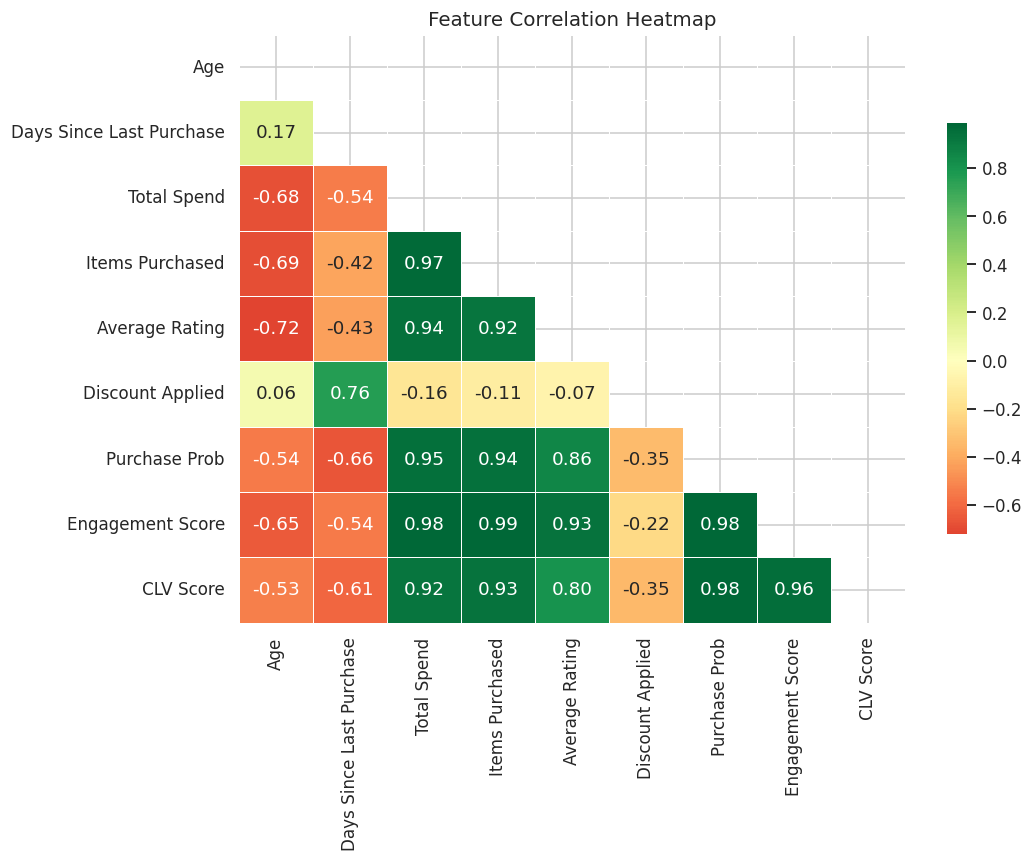

Saved: eda_correlation.png ✅


In [10]:
scaled_cols = [c for c in df.columns if c.endswith('_Scaled')]
extra = ['Purchase_Prob', 'Engagement_Score', 'CLV_Score']
corr_cols = scaled_cols + [c for c in extra if c in df.columns]

if corr_cols:
    corr = df[corr_cols].corr()
    # Shorten labels
    corr.columns = [c.replace('_Scaled','').replace('_',' ') for c in corr.columns]
    corr.index   = [c.replace('_Scaled','').replace('_',' ') for c in corr.index]

    fig, ax = plt.subplots(figsize=(10, 8))
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
                center=0, ax=ax, linewidths=0.4, cbar_kws={'shrink': 0.7})
    ax.set_title('Feature Correlation Heatmap', fontsize=13)
    plt.tight_layout()
    plt.savefig('eda_correlation.png', bbox_inches='tight')
    plt.show()
    print('Saved: eda_correlation.png ✅')

## 6. Categorical Breakdowns

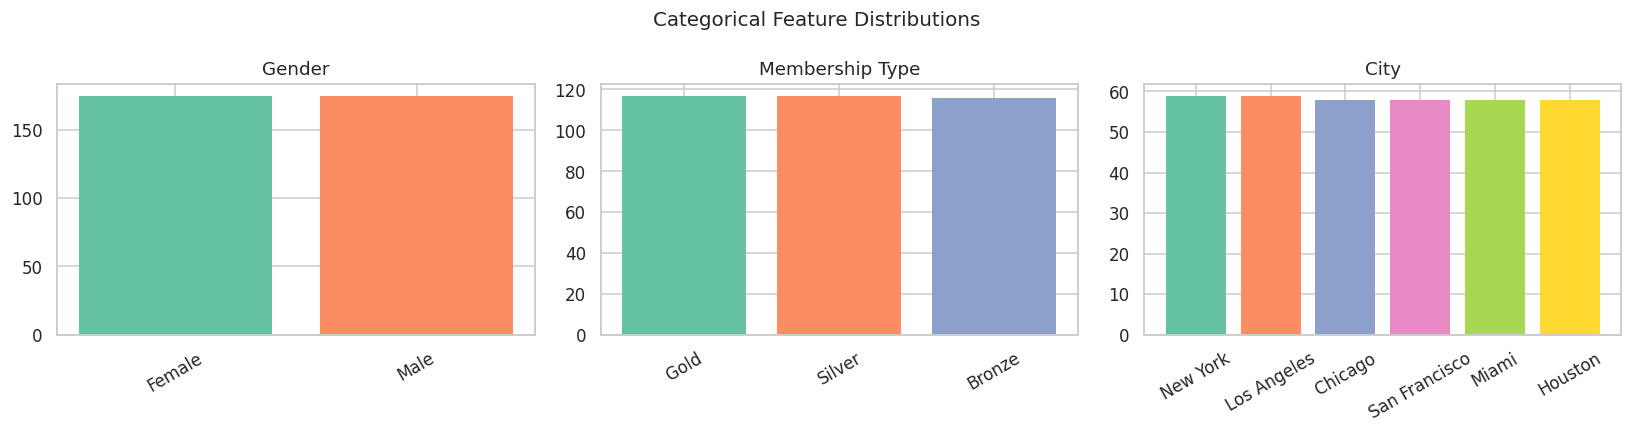

Saved: eda_categorical.png ✅


In [11]:
cat_cols = [c for c in ['Gender', 'Membership Type', 'City'] if c in df.columns]

fig, axes = plt.subplots(1, len(cat_cols), figsize=(5 * len(cat_cols), 4))
if len(cat_cols) == 1:
    axes = [axes]

for ax, col in zip(axes, cat_cols):
    counts = df[col].value_counts()
    ax.bar(counts.index, counts.values,
           color=sns.color_palette('Set2', len(counts)), edgecolor='none')
    ax.set_title(col)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=30)

fig.suptitle('Categorical Feature Distributions', fontsize=13)
plt.tight_layout()
plt.savefig('eda_categorical.png', bbox_inches='tight')
plt.show()
print('Saved: eda_categorical.png ✅')

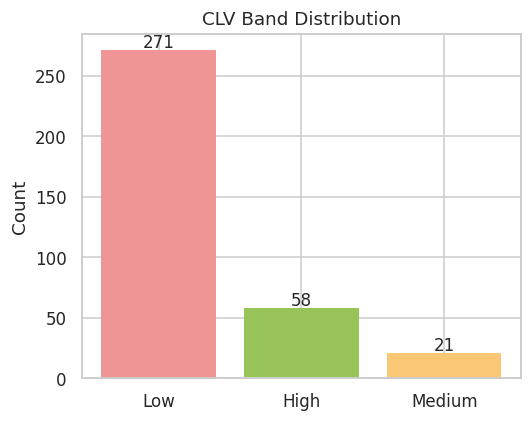

Saved: eda_clv_band.png ✅


In [12]:
# CLV Band distribution
if 'CLV_Band' in df.columns:
    fig, ax = plt.subplots(figsize=(5, 4))
    counts = df['CLV_Band'].value_counts()
    colors = {'Low': '#F09595', 'Medium': '#FAC775', 'High': '#97C459'}
    bar_colors = [colors.get(str(k), '#999') for k in counts.index]
    ax.bar(counts.index.astype(str), counts.values, color=bar_colors, edgecolor='none')
    ax.set_title('CLV Band Distribution')
    ax.set_ylabel('Count')
    for i, (val) in enumerate(counts.values):
        ax.text(i, val + 2, str(val), ha='center', fontsize=11)
    plt.tight_layout()
    plt.savefig('eda_clv_band.png', bbox_inches='tight')
    plt.show()
    print('Saved: eda_clv_band.png ✅')

## 7. Key Insights Summary

In [13]:
print('=' * 55)
print('   EDA KEY INSIGHTS')
print('=' * 55)

if 'Total Spend' in df.columns:
    print(f'Avg Total Spend      : {df["Total Spend"].mean():.2f}')
    print(f'Median Total Spend   : {df["Total Spend"].median():.2f}')

if 'Items Purchased' in df.columns:
    print(f'Avg Items Purchased  : {df["Items Purchased"].mean():.2f}')

if 'Days Since Last Purchase' in df.columns:
    print(f'Avg Days Since Last  : {df["Days Since Last Purchase"].mean():.1f}')

if 'CLV_Band' in df.columns:
    print(f"\nCLV Band Counts:\n{df['CLV_Band'].value_counts().to_string()}")

if 'Segment' in df.columns:
    print(f"\nSegment Counts:\n{df['Segment'].value_counts().to_string()}")

print('\n✅ EDA complete — charts saved as PNG files in notebooks/')

   EDA KEY INSIGHTS
Avg Total Spend      : 845.38
Median Total Spend   : 775.20
Avg Items Purchased  : 12.60
Avg Days Since Last  : 26.6

CLV Band Counts:
CLV_Band
Low       271
High       58
Medium     21

Segment Counts:
Segment
Lost         82
At-Risk      59
Segment 4    59
Loyalists    58
Champions    58
Segment 5    34

✅ EDA complete — charts saved as PNG files in notebooks/
